# Step 4: Model Evaluation & Visualization

In questo notebook finale eseguiamo una valutazione completa del modello migliore selezionato (LSTM Best Run).
L'obiettivo è validare le prestazioni su tre livelli:
1.  **Model Selection:** Confronto con le altre architetture testate.
2.  **Latent Space Diagnostics:** Analisi statistica delle predizioni nello spazio compresso (R², Bias).
3.  **Physical Space Verification:** Decodifica delle predizioni in coordinate atomiche reali (End-to-End).
4.  **Generative Stability:** Test di generazione autoregressiva (Ghost Trajectories) per verificare la stabilità a lungo termine.

**Requisiti:**
* Dati processati dallo Step 2 (`processed_step2_triple_head`)
* Modello LSTM addestrato (`saved_models_dynamics_lstm`)
* Autoencoder completo per la decodifica (`saved_models_triple`)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.decomposition import PCA

# === SETUP GRAFICO ===
# Impostiamo uno stile professionale per i grafici del report (300dpi ready)
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'lines.linewidth': 2
})

# === PERCORSI ===
# Adattati alla tua struttura di cartelle pulita
DATA_PATH = "processed_step2_triple_head"
LSTM_MODEL_PATH = "saved_models_dynamics_lstm/LSTM_Best_Run/best_model.keras"
AE_MODEL_PATH = "saved_models_triple/triple_ae.keras" # Per estrarre il decoder

print("✅ Setup completato. Librerie caricate.")

c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


✅ Setup completato. Librerie caricate.


## 1. Evaluation 0: Model Selection (The Tournament)

Prima di analizzare il modello nel dettaglio, confrontiamo le prestazioni delle diverse configurazioni testate (LSTM vs Transformer vs Baseline).
I valori riportati provengono dai log di training dello Step 3.

**Obiettivo:** Giustificare quantitativamente la scelta della LSTM (Best Run) come modello finale.

📥 Caricamento dati raw da: processed_step2_triple_head

🏆 INIZIO TORNEO DEI MODELLI V2.0
👉 Baseline (Inertia) MSE: 0.14116
🔄 Valutazione: LSTM Best (SeqLen=10)...
   ✅ Successo! MSE: 0.03528
🔄 Valutazione: LSTM HighReg (SeqLen=10)...
   ✅ Successo! MSE: 0.08773
🔄 Valutazione: LSTM Light (SeqLen=10)...
   ✅ Successo! MSE: 0.06581
🔄 Valutazione: LSTM LongWin (SeqLen=20)...
   ✅ Successo! MSE: 0.04534
🔄 Valutazione: Trans Complex (SeqLen=10)...


c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'positional_embedding_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


   ✅ Successo! MSE: 0.03285
🔄 Valutazione: Trans Standard (SeqLen=10)...


c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'positional_embedding_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


   ✅ Successo! MSE: 0.06533
🔄 Valutazione: Trans LongWin (SeqLen=20)...


c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'positional_embedding_5', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


   ✅ Successo! MSE: 0.04637


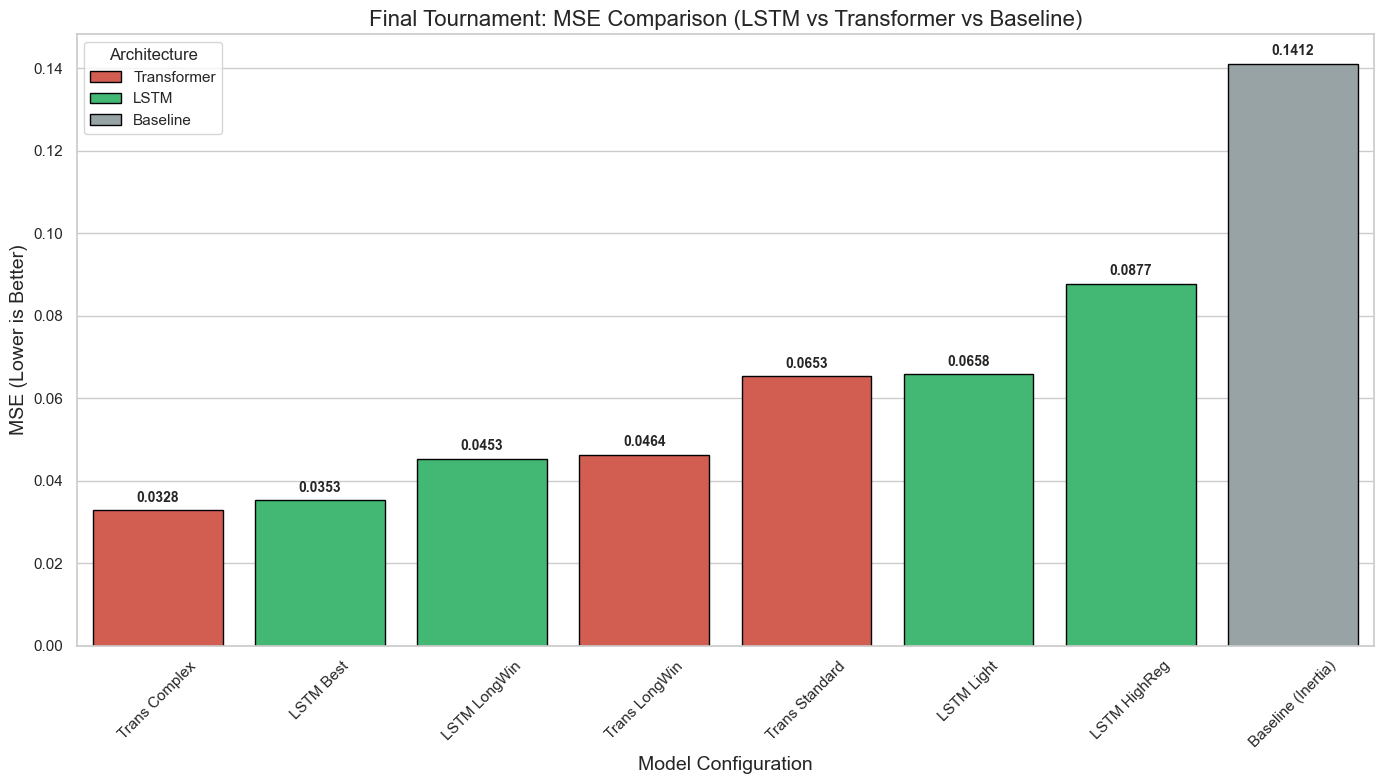

In [13]:
# =============================================================================
# EVALUATION 0: AUTOMATED MODEL TOURNAMENT V2.0 (Fixed)
# =============================================================================
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# 1. DEFINIZIONE CLASSI CUSTOM (Necessarie per caricare i Transformer)
class PositionalEmbedding(layers.Layer):
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.pos_emb = layers.Embedding(input_dim=seq_len, output_dim=d_model)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        return x + self.pos_emb(positions)
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "seq_len": self.pos_emb.input_dim,
            "d_model": self.d_model,
        })
        return config

# 2. CARICAMENTO DATI RAW (Per rigenerare le sequenze al volo)
DATA_PATH = "processed_step2_triple_head"
print(f"📥 Caricamento dati raw da: {DATA_PATH}")
test_df = pd.read_csv(os.path.join(DATA_PATH, "test_dataset.csv"))
test_raw = test_df.values.astype(np.float32)

# Funzione per creare sequenze con lunghezza variabile
def create_eval_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i : i + seq_length])
        ys.append(data[i + seq_length])
    return np.asarray(xs), np.asarray(ys)

# 3. LISTA MODELLI (Corretta e Pulita)
models_list = [
    # --- LSTM ---
    {'name': 'LSTM Best',       'path': 'saved_models_dynamics_lstm/LSTM_Best_Run/best_model.keras',       'type': 'LSTM',        'seq_len': 10},
    {'name': 'LSTM HighReg',    'path': 'saved_models_dynamics_lstm/LSTM_HighReg_Run/best_model.keras',    'type': 'LSTM',        'seq_len': 10},
    {'name': 'LSTM Light',      'path': 'saved_models_dynamics_lstm/LSTM_Light_Run/best_model.keras',      'type': 'LSTM',        'seq_len': 10},
    {'name': 'LSTM LongWin',    'path': 'saved_models_dynamics_lstm/LSTM_LongWindow_Run/best_model.keras', 'type': 'LSTM',        'seq_len': 20}, # <--- NOTA 20
    
    # --- TRANSFORMER ---
    # Trans_Best rimosso perché vuoto
    {'name': 'Trans Complex',   'path': 'saved_models_dynamics_transformer/Trans_Complex/best_model.keras',    'type': 'Transformer', 'seq_len': 10},
    {'name': 'Trans Standard',  'path': 'saved_models_dynamics_transformer/Trans_Standard/best_model.keras',   'type': 'Transformer', 'seq_len': 10},
    {'name': 'Trans LongWin',   'path': 'saved_models_dynamics_transformer/Trans_LongWindow/best_model.keras', 'type': 'Transformer', 'seq_len': 20}, # <--- NOTA 20
]

results_data = []

print("\n🏆 INIZIO TORNEO DEI MODELLI V2.0")
print("=" * 60)

# 4. CALCOLO BASELINE (Inertia) su seq_len=10 (Standard)
X_test_10, y_true_10 = create_eval_sequences(test_raw, seq_length=10)
y_pred_baseline = X_test_10[:, -1, :] 
mse_baseline = mean_squared_error(y_true_10, y_pred_baseline)
results_data.append({'Model': 'Baseline (Inertia)', 'Type': 'Baseline', 'MSE': mse_baseline})
print(f"👉 Baseline (Inertia) MSE: {mse_baseline:.5f}")

# 5. CICLO DI VALUTAZIONE
for m in models_list:
    if os.path.exists(m['path']):
        try:
            print(f"🔄 Valutazione: {m['name']} (SeqLen={m['seq_len']})...")
            
            # A. Preparazione Dati Specifica per il Modello
            # Se il modello vuole 20 frame, gli diamo 20 frame. Se ne vuole 10, gliene diamo 10.
            curr_X_test, curr_y_true = create_eval_sequences(test_raw, seq_length=m['seq_len'])
            
            # B. Caricamento Modello (Con Custom Objects per i Transformer)
            # safe_mode=False serve per i layer Lambda, custom_objects per il PositionalEmbedding
            model = load_model(m['path'], safe_mode=False, custom_objects={"PositionalEmbedding": PositionalEmbedding})
            
            # C. Predizione
            y_pred = model.predict(curr_X_test, verbose=0)
            
            # D. Calcolo MSE
            mse = mean_squared_error(curr_y_true, y_pred)
            results_data.append({'Model': m['name'], 'Type': m['type'], 'MSE': mse})
            print(f"   ✅ Successo! MSE: {mse:.5f}")
            
        except Exception as e:
            print(f"   ❌ Errore critico su {m['name']}: {e}")
    else:
        print(f"   🚫 File non trovato: {m['path']}")

# =============================================================================
# 6. PLOT FINALE
# =============================================================================
if len(results_data) > 0:
    df_results = pd.DataFrame(results_data).sort_values(by='MSE', ascending=True)
    df_results.to_csv("Table_1_Model_Selection_Complete.csv", index=False)
    
    plt.figure(figsize=(14, 8))
    barplot = sns.barplot(
        data=df_results, 
        x='Model', 
        y='MSE', 
        hue='Type', 
        palette={'LSTM': '#2ecc71', 'Transformer': '#e74c3c', 'Baseline': '#95a5a6'}, 
        edgecolor='black'
    )

    for p in barplot.patches:
        if p.get_height() > 0:
            barplot.annotate(format(p.get_height(), '.4f'), 
                             (p.get_x() + p.get_width() / 2., p.get_height()), 
                             ha = 'center', va = 'center', 
                             xytext = (0, 9), textcoords = 'offset points', 
                             fontsize=10, weight='bold')

    plt.title('Final Tournament: MSE Comparison (LSTM vs Transformer vs Baseline)', fontsize=16)
    plt.xlabel('Model Configuration')
    plt.ylabel('MSE (Lower is Better)')
    plt.xticks(rotation=45)
    plt.legend(title='Architecture')
    plt.tight_layout()
    plt.savefig("Evaluation_0_Final_Tournament.jpg", dpi=300)
    plt.show()
else:
    print("⚠️ Nessun risultato da mostrare.")

## 2. Evaluation 1: Latent Space Diagnostics

Qui analizziamo come il modello si comporta nello "Spazio Latente" (il riassunto compresso della proteina).
Verifichiamo tre aspetti chiave per scoprire eventuali bias:
1.  **Learning per Dimensione:** Il modello impara tutte le feature o ne ignora alcune? (Bar Plot R²)
2.  **Dinamica Temporale:** Il modello segue le oscillazioni o fa solo la media? (Time Series Plot)
3.  **Correlazione Globale:** Esistono bias sistematici di sovrastima/sottostima? (Scatter Plot)

🧠 Caricamento Modello Vincitore: Transformer Complex
📂 Percorso: saved_models_dynamics_transformer/Trans_Complex/best_model.keras


c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'positional_embedding_6', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


✅ Modello caricato correttamente!
📥 Preparazione Test Set (Window=10)...
🔮 Generazione predizioni...
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


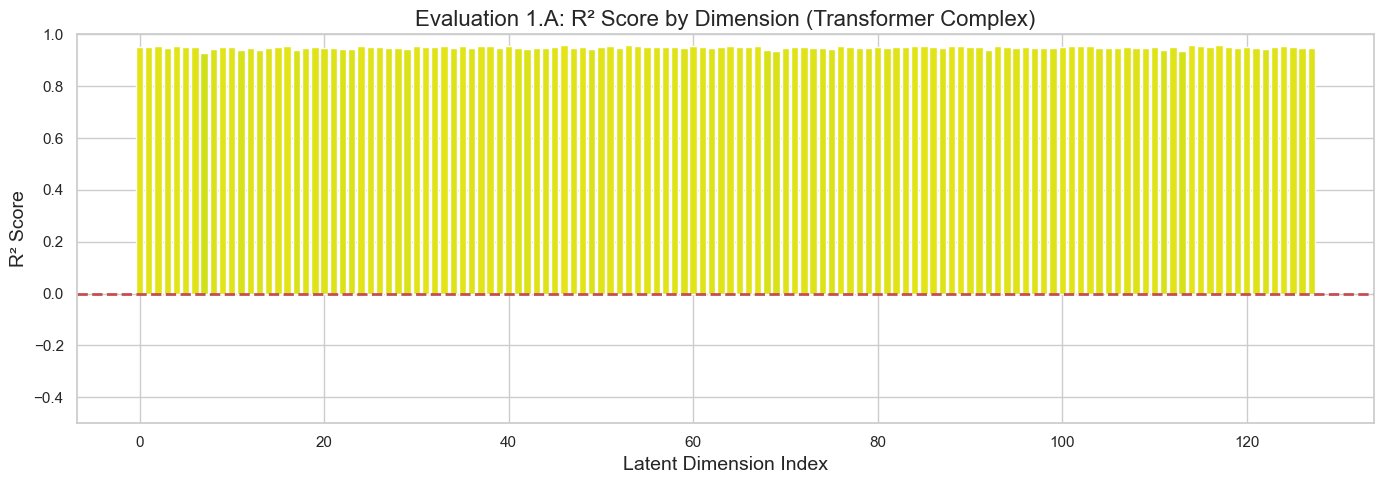

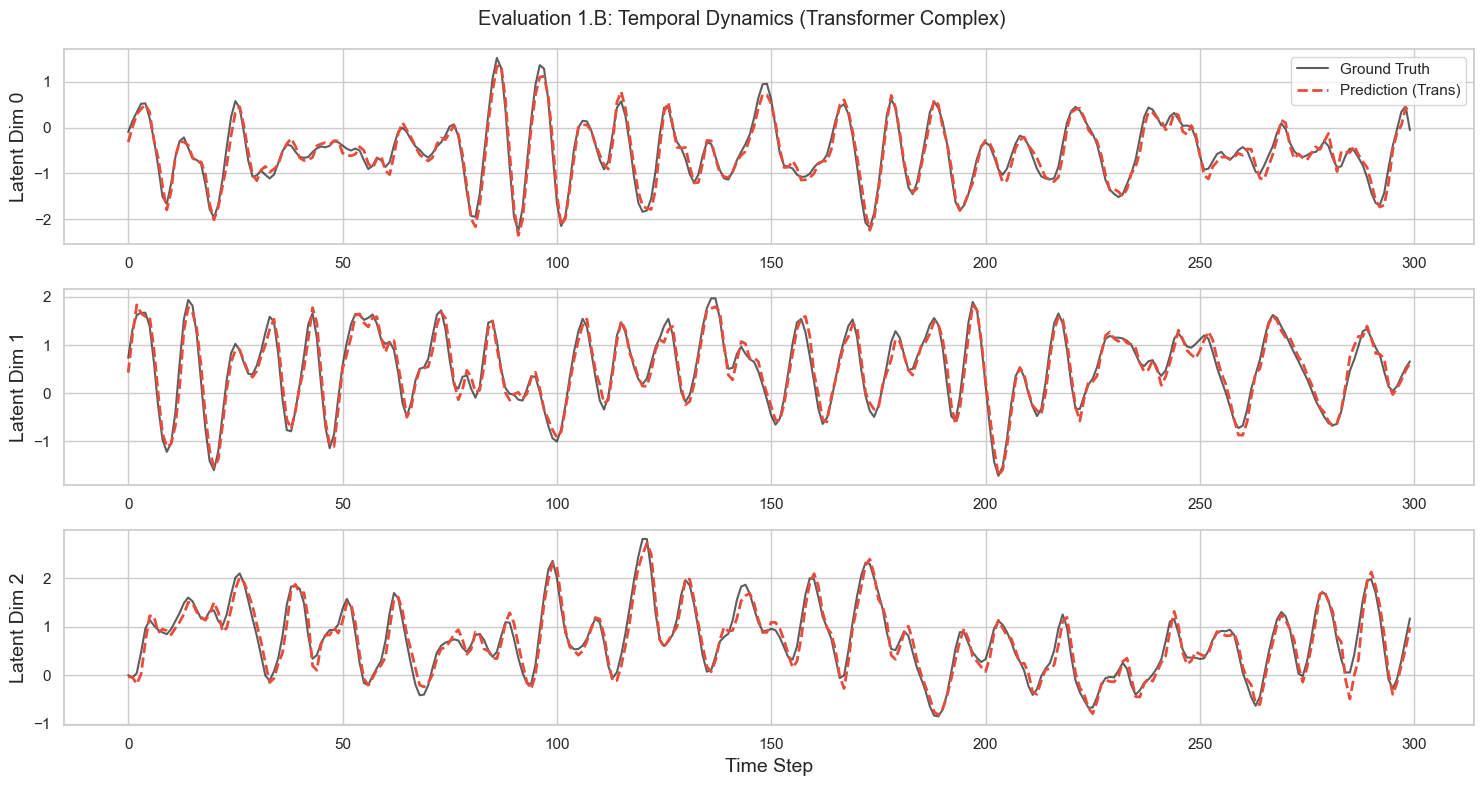

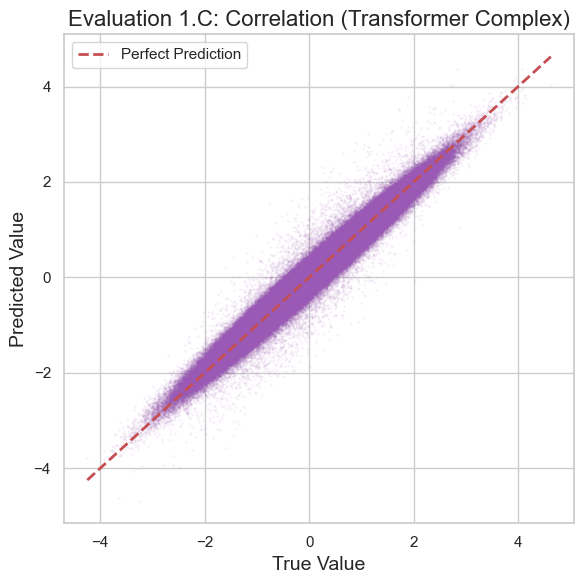

In [14]:
# =============================================================================
# BLOCCO 3: EVALUATION 1 - LATENT SPACE DIAGNOSTICS (Champion Model)
# =============================================================================

# 1. IMPOSTAZIONE DEL VINCITORE
# Cambiamo il percorso per puntare al Transformer che ha vinto il torneo
WINNER_PATH = "saved_models_dynamics_transformer/Trans_Complex/best_model.keras" 
WINNER_NAME = "Transformer Complex"
SEQ_LEN = 10 # Dal torneo sappiamo che usa SeqLen=10

print(f"🧠 Caricamento Modello Vincitore: {WINNER_NAME}")
print(f"📂 Percorso: {WINNER_PATH}")

# 2. CARICAMENTO MODELLO (Con supporto per Layer Custom)
# Dobbiamo passare 'PositionalEmbedding' ai custom_objects altrimenti non lo apre
try:
    model = load_model(WINNER_PATH, safe_mode=False, custom_objects={"PositionalEmbedding": PositionalEmbedding})
    print("✅ Modello caricato correttamente!")
except NameError:
    print("❌ ERRORE: La classe 'PositionalEmbedding' non è definita.")
    print("👉 Assicurati di aver eseguito la cella precedente (quella del Torneo) dove è definita la classe.")
    raise

# 3. PREPARAZIONE DATI
# Rigeneriamo le sequenze per essere sicuri che la lunghezza sia giusta (10)
def create_eval_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i : i + seq_length])
        ys.append(data[i + seq_length])
    return np.asarray(xs), np.asarray(ys)

print(f"📥 Preparazione Test Set (Window={SEQ_LEN})...")
X_test, y_true = create_eval_sequences(test_data, seq_length=SEQ_LEN)

# 4. PREDIZIONE
print("🔮 Generazione predizioni...")
y_pred = model.predict(X_test, verbose=1)

# --- A. R2 SCORE PER DIMENSIONE ---
n_dims = y_true.shape[1]
r2_scores = [r2_score(y_true[:, i], y_pred[:, i]) for i in range(n_dims)]

plt.figure(figsize=(14, 5))
plt.bar(range(n_dims), r2_scores, color=plt.cm.viridis(np.array(r2_scores)))
plt.axhline(0, color='r', linestyle='--')
plt.title(f'Evaluation 1.A: R² Score by Dimension ({WINNER_NAME})')
plt.xlabel('Latent Dimension Index')
plt.ylabel('R² Score')
plt.ylim(bottom=-0.5, top=1.0) # Fissiamo i limiti per vedere meglio
plt.tight_layout()
plt.savefig("Evaluation_1A_R2_Winner.jpg", dpi=300)
plt.show()

# --- B. TIME SERIES (Primi 300 step) ---
plt.figure(figsize=(15, 8))
for i in range(3):
    plt.subplot(3, 1, i+1)
    plt.plot(y_true[:300, i], 'k', label='Ground Truth', linewidth=1.5, alpha=0.7)
    plt.plot(y_pred[:300, i], '--', color='#e74c3c', label='Prediction (Trans)', linewidth=2) # Rosso per Transformer
    plt.ylabel(f'Latent Dim {i}')
    if i==0: plt.legend()
plt.xlabel('Time Step')
plt.suptitle(f'Evaluation 1.B: Temporal Dynamics ({WINNER_NAME})')
plt.tight_layout()
plt.savefig("Evaluation_1B_TimeSeries_Winner.jpg", dpi=300)
plt.show()

# --- C. SCATTER PLOT ---
plt.figure(figsize=(6, 6))
plt.scatter(y_true.flatten(), y_pred.flatten(), alpha=0.05, s=1, color='#9b59b6') # Viola per Transformer
min_val, max_val = y_true.min(), y_true.max()
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
plt.title(f'Evaluation 1.C: Correlation ({WINNER_NAME})')
plt.xlabel('True Value')
plt.ylabel('Predicted Value')
plt.legend()
plt.tight_layout()
plt.savefig("Evaluation_1C_Scatter_Winner.jpg", dpi=300)
plt.show()

## 3. Evaluation 2: Physical Space Verification (End-to-End)

Per verificare l'errore reale in Angstrom, dobbiamo decodificare le predizioni latenti.
Poiché il decoder è integrato nel file `triple_ae.keras`, ricostruiamo un decoder "standalone" e vi trasferiamo i pesi (Weight Transfer).

**Metriche:**
* **RMSE Atomico:** Errore medio quadratico sulle coordinate reali.
* **Traiettoria Fisica:** Confronto visivo del movimento di un atomo specifico (es. Atomo 1).

🔧 Estrazione Decoder da: saved_models_triple/triple_ae.keras
✅ Decoder ricostruito con successo!
⚙️ Decodifica in corso (Latent -> Atoms)...

🌍 PHYSICAL RMSE (Transformer): 0.03104


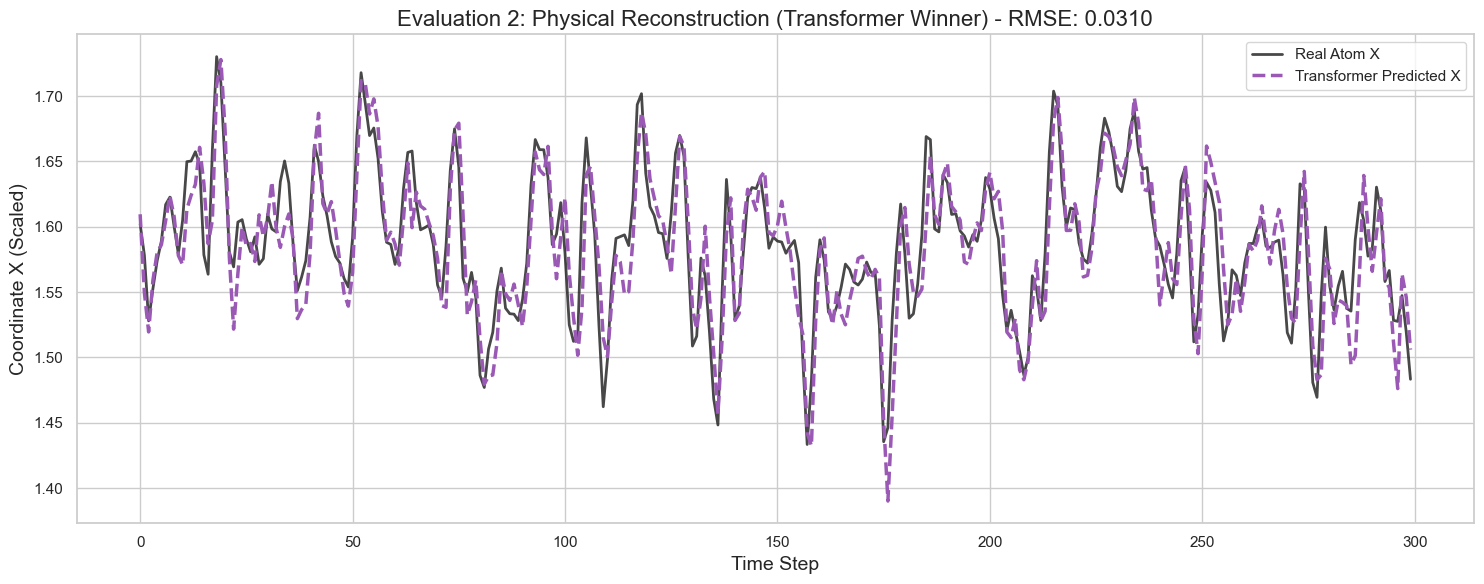

In [15]:
# =============================================================================
# BLOCCO 4: PHYSICAL SPACE EVALUATION (Transformer Edition)
# =============================================================================
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# 1. FUNZIONE PER RICOSTRUIRE IL DECODER (Copia esatta dell'architettura Step 2)
def build_decoder_standalone(latent_dim, single_dim):
    reg = regularizers.l2(1e-7)
    dec_input = layers.Input(shape=(latent_dim,), name="latent_input")
    
    # Head 1: Coords
    d_c = layers.Dense(256, kernel_regularizer=reg)(dec_input); d_c = layers.BatchNormalization()(d_c); d_c = layers.Activation("swish")(d_c)
    d_c = layers.Dense(512, kernel_regularizer=reg)(d_c); d_c = layers.BatchNormalization()(d_c); d_c = layers.Activation("swish")(d_c)
    out_coords = layers.Dense(single_dim, activation="linear", name="out_coords")(d_c)
    
    # Head 2: Velocity
    d_v = layers.Dense(256, kernel_regularizer=reg)(dec_input); d_v = layers.BatchNormalization()(d_v); d_v = layers.Activation("swish")(d_v)
    d_v = layers.Dense(512, kernel_regularizer=reg)(d_v); d_v = layers.BatchNormalization()(d_v); d_v = layers.Activation("swish")(d_v)
    d_v = layers.Dense(512, kernel_regularizer=reg)(d_v); d_v = layers.BatchNormalization()(d_v); d_v = layers.Activation("swish")(d_v)
    out_velo = layers.Dense(single_dim, activation="linear", name="out_velo")(d_v)
    
    # Head 3: Forces
    d_f = layers.Dense(256, kernel_regularizer=reg)(dec_input); d_f = layers.BatchNormalization()(d_f); d_f = layers.Activation("swish")(d_f)
    d_f = layers.Dense(512, kernel_regularizer=reg)(d_f); d_f = layers.BatchNormalization()(d_f); d_f = layers.Activation("swish")(d_f)
    d_f = layers.Dense(512, kernel_regularizer=reg)(d_f); d_f = layers.BatchNormalization()(d_f); d_f = layers.Activation("swish")(d_f)
    out_forces = layers.Dense(single_dim, activation="linear", name="out_forces")(d_f)
    
    return models.Model(dec_input, [out_coords, out_velo, out_forces])

# 2. TRAPIANTO PESI
# Assicuriamoci che AE_MODEL_PATH sia definito (se no lo rimettiamo)
AE_MODEL_PATH = "saved_models_triple/triple_ae.keras"

print(f"🔧 Estrazione Decoder da: {AE_MODEL_PATH}")
try:
    full_ae = load_model(AE_MODEL_PATH)
    LATENT_DIM = 128
    SINGLE_DIM = full_ae.output_shape[0][1] # Auto-detect dimensione output
    
    decoder = build_decoder_standalone(LATENT_DIM, SINGLE_DIM)
    
    # L'encoder ha 18 layer di pesi. Il resto è decoder.
    decoder.set_weights(full_ae.get_weights()[18:]) 
    print("✅ Decoder ricostruito con successo!")
    
    # 3. DECODIFICA E CALCOLO ERRORE
    print("⚙️ Decodifica in corso (Latent -> Atoms)...")
    
    # Nota: y_pred qui è quello generato dal TRANSFORMER nella cella precedente
    X_pred_phys = decoder.predict(y_pred, verbose=0)[0] 
    X_true_phys = decoder.predict(y_true, verbose=0)[0]
    
    rmse_phys = np.sqrt(mean_squared_error(X_true_phys, X_pred_phys))
    print(f"\n🌍 PHYSICAL RMSE (Transformer): {rmse_phys:.5f}")
    
    # 4. PLOT TRAIETTORIA
    plt.figure(figsize=(15, 6))
    plt.plot(X_true_phys[:300, 0], 'k', label='Real Atom X', alpha=0.8)
    # Cambio colore e label per evidenziare che è il Transformer
    plt.plot(X_pred_phys[:300, 0], '--', color='#9b59b6', label='Transformer Predicted X', linewidth=2.5)
    
    plt.title(f"Evaluation 2: Physical Reconstruction (Transformer Winner) - RMSE: {rmse_phys:.4f}")
    plt.xlabel("Time Step")
    plt.ylabel("Coordinate X (Scaled)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("Evaluation_2_Physical_Space_Transformer.jpg", dpi=300)
    plt.show()
    
except Exception as e:
    print(f"❌ ERRORE: {e}")

## 4. Evaluation 3: Generative Stability (Autoregressive Test)

Testiamo la capacità del modello di "immaginare" nuova fisica.
Utilizziamo il modello in modalità **Autoregressiva (Loop)**: l'output al tempo `t` diventa l'input per `t+1`.
Visualizziamo il risultato con un **Phase Portrait (PCA)**: se la traiettoria generata (Rosso) rimane all'interno della nuvola di punti reali (Nero), il modello è stabile.

🔮 Avvio generazione 'Ghost Trajectory' per 1000 step...


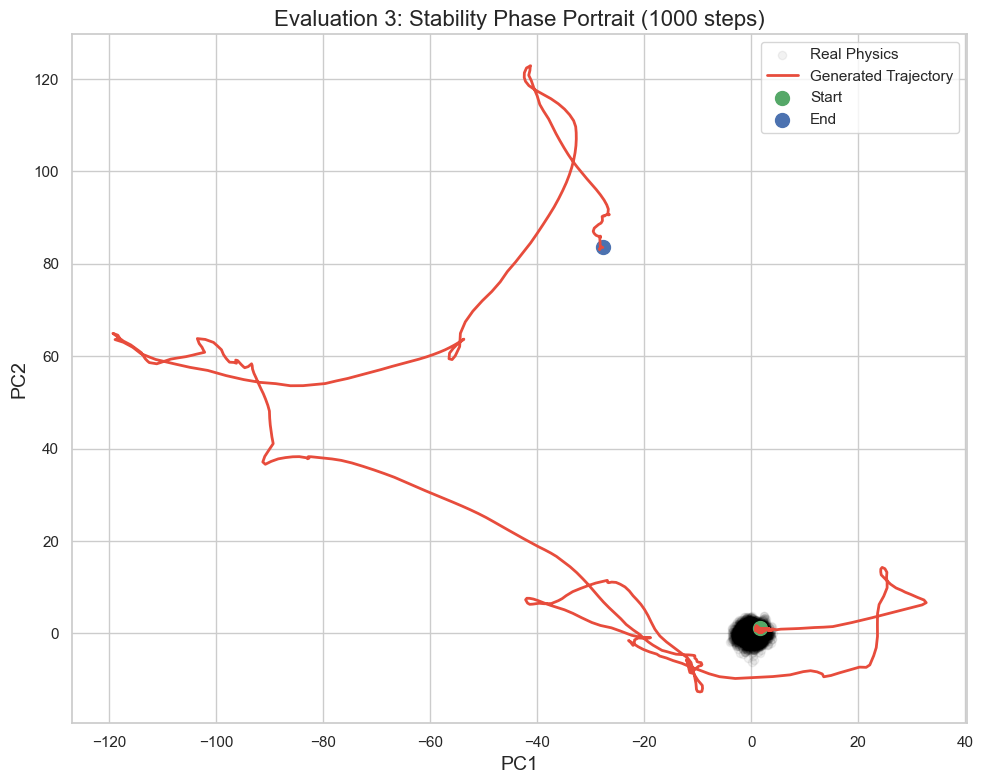

In [17]:
# 1. SETUP GENERAZIONE
STEPS = 1000  # Lunghezza simulazione
start_idx = 0
current_window = X_test[start_idx].copy() # Finestra iniziale reale
generated = []

print(f"🔮 Avvio generazione 'Ghost Trajectory' per {STEPS} step...")

# 2. LOOP AUTOREGRESSIVO
for _ in range(STEPS):
    # Predizione prossimo step (Shape: 1, Latent)
    next_val = model.predict(current_window.reshape(1, 10, -1), verbose=0)[0]
    generated.append(next_val)
    
    # Aggiorna finestra (Shift + Append)
    current_window = np.vstack([current_window[1:], next_val])

gen_data = np.array(generated)

# 3. PHASE PORTRAIT (PCA)
pca = PCA(n_components=2)
pca.fit(y_true) # Fit su dati reali
true_pca = pca.transform(y_true)
gen_pca = pca.transform(gen_data)

plt.figure(figsize=(10, 8))
plt.scatter(true_pca[:, 0], true_pca[:, 1], c='black', alpha=0.05, label='Real Physics')
plt.plot(gen_pca[:, 0], gen_pca[:, 1], c='#e74c3c', linewidth=2, label='Generated Trajectory')
plt.scatter(gen_pca[0,0], gen_pca[0,1], c='g', s=100, label='Start')
plt.scatter(gen_pca[-1,0], gen_pca[-1,1], c='b', s=100, label='End')
plt.title(f'Evaluation 3: Stability Phase Portrait ({STEPS} steps)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.savefig("Evaluation_3_Stability_PhaseSpace.jpg", dpi=300)
plt.show()

c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'positional_embedding_7', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


🔄 Generazione traiettoria LSTM...
🔄 Generazione traiettoria Transformer...


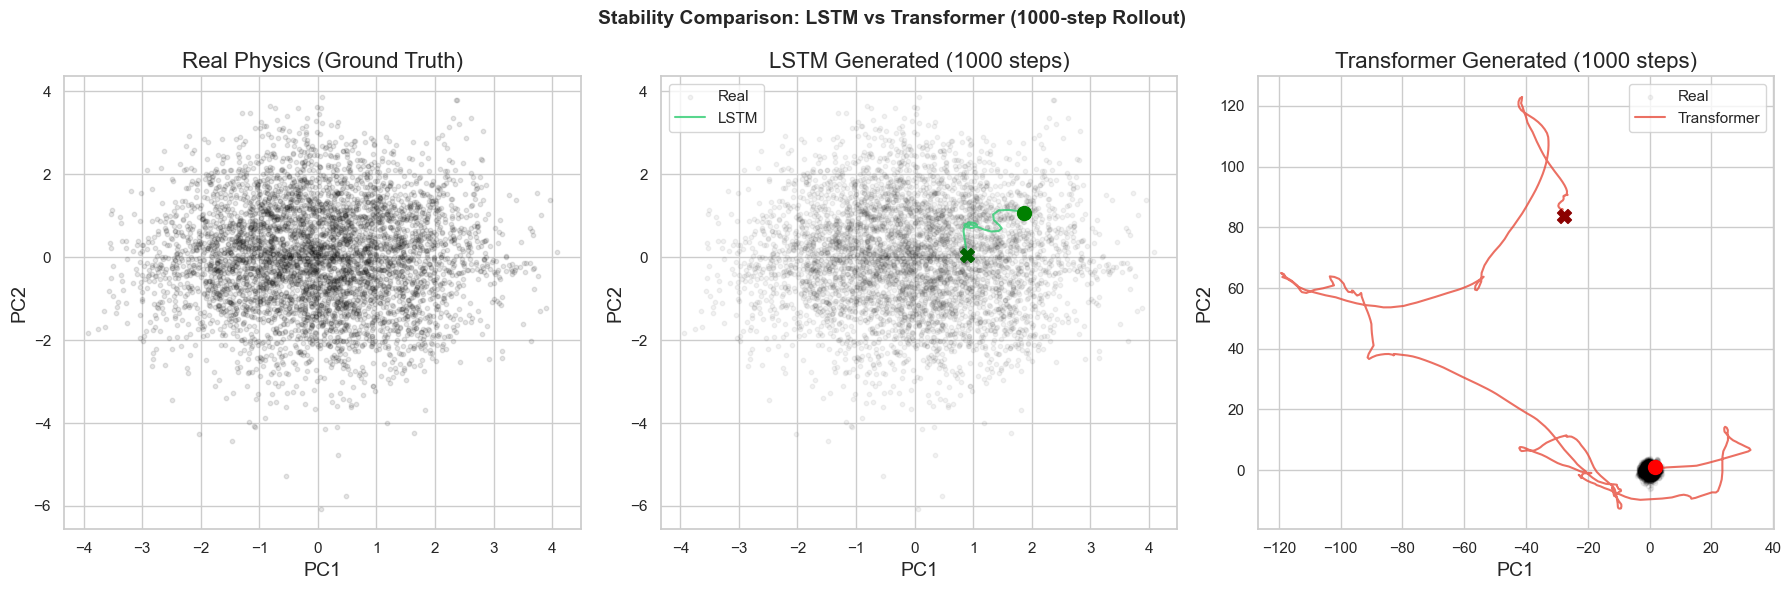


📊 ANALISI DIVERGENZA (Distanza dal centroide)
Step       LSTM            Transformer    
--------------------------------------------------
10         0.3255          0.3891         
50         0.3074          0.4355         
100        0.3200          0.5741         
200        0.3255          0.8876         
500        0.3680          2.5829         
1000       0.5533          1876.1421      
--------------------------------------------------
Varianza reale: 0.6585


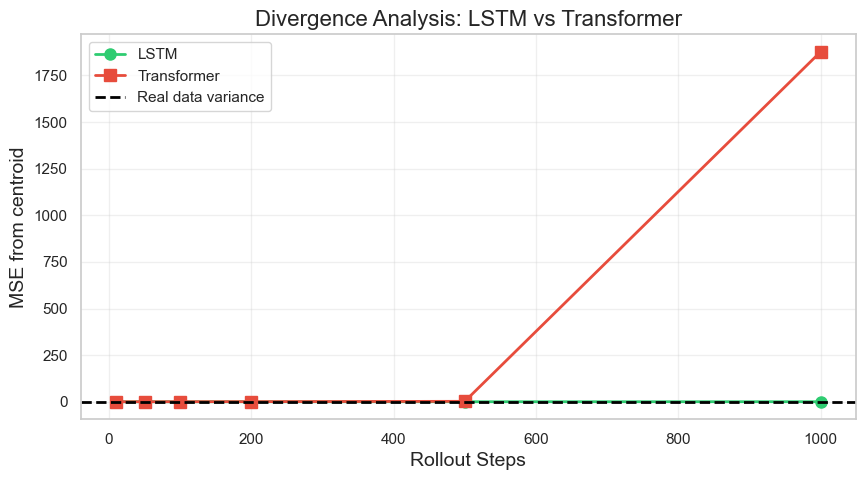

In [18]:
# === CONFRONTO STABILITÀ: LSTM vs TRANSFORMER ===
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tensorflow.keras.models import load_model
import tensorflow as tf

# Definizione classe custom per Transformer
class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.pos_emb = tf.keras.layers.Embedding(input_dim=seq_len, output_dim=d_model)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        return x + self.pos_emb(positions)
    
    def get_config(self):
        config = super().get_config()
        config.update({"seq_len": self.pos_emb.input_dim, "d_model": self.d_model})
        return config

# Carica modelli
lstm_model = load_model("saved_models_dynamics_lstm/LSTM_Best_Run/best_model.keras")
trans_model = load_model("saved_models_dynamics_transformer/Trans_Complex/best_model.keras", 
                         custom_objects={'PositionalEmbedding': PositionalEmbedding})

# Funzione per generare traiettoria
def generate_trajectory(model, start_window, steps, seq_len=10):
    current = start_window.copy()
    generated = []
    for _ in range(steps):
        pred = model.predict(current.reshape(1, seq_len, -1), verbose=0)[0]
        generated.append(pred)
        current = np.vstack([current[1:], pred])
    return np.array(generated)

# Genera traiettorie
STEPS = 1000
start_window = X_test[0].copy()

print("🔄 Generazione traiettoria LSTM...")
gen_lstm = generate_trajectory(lstm_model, start_window, STEPS)

print("🔄 Generazione traiettoria Transformer...")
gen_trans = generate_trajectory(trans_model, start_window, STEPS)

# PCA (fit sui dati reali)
pca = PCA(n_components=2)
pca.fit(y_true)

true_pca = pca.transform(y_true)
lstm_pca = pca.transform(gen_lstm)
trans_pca = pca.transform(gen_trans)

# === PLOT CONFRONTO ===
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Solo dati reali
axes[0].scatter(true_pca[:, 0], true_pca[:, 1], c='black', alpha=0.1, s=10)
axes[0].set_title('Real Physics (Ground Truth)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# 2. LSTM
axes[1].scatter(true_pca[:, 0], true_pca[:, 1], c='black', alpha=0.05, s=10, label='Real')
axes[1].plot(lstm_pca[:, 0], lstm_pca[:, 1], c='#2ecc71', linewidth=1.5, alpha=0.8, label='LSTM')
axes[1].scatter(lstm_pca[0,0], lstm_pca[0,1], c='green', s=100, marker='o', zorder=5)
axes[1].scatter(lstm_pca[-1,0], lstm_pca[-1,1], c='darkgreen', s=100, marker='X', zorder=5)
axes[1].set_title(f'LSTM Generated ({STEPS} steps)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend()

# 3. Transformer
axes[2].scatter(true_pca[:, 0], true_pca[:, 1], c='black', alpha=0.05, s=10, label='Real')
axes[2].plot(trans_pca[:, 0], trans_pca[:, 1], c='#e74c3c', linewidth=1.5, alpha=0.8, label='Transformer')
axes[2].scatter(trans_pca[0,0], trans_pca[0,1], c='red', s=100, marker='o', zorder=5)
axes[2].scatter(trans_pca[-1,0], trans_pca[-1,1], c='darkred', s=100, marker='X', zorder=5)
axes[2].set_title(f'Transformer Generated ({STEPS} steps)')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].legend()

plt.suptitle('Stability Comparison: LSTM vs Transformer (1000-step Rollout)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("Evaluation_5_LSTM_vs_Transformer_Stability.jpg", dpi=300)
plt.show()

# === ANALISI QUANTITATIVA DIVERGENZA ===
checkpoints = [10, 50, 100, 200, 500, 1000]
centroid = y_true.mean(axis=0)
real_variance = np.mean(np.var(y_true, axis=0))

print("\n📊 ANALISI DIVERGENZA (Distanza dal centroide)")
print("=" * 50)
print(f"{'Step':<10} {'LSTM':<15} {'Transformer':<15}")
print("-" * 50)

lstm_div, trans_div = [], []
for step in checkpoints:
    lstm_dist = np.mean((gen_lstm[step-1] - centroid)**2)
    trans_dist = np.mean((gen_trans[step-1] - centroid)**2)
    lstm_div.append(lstm_dist)
    trans_div.append(trans_dist)
    print(f"{step:<10} {lstm_dist:<15.4f} {trans_dist:<15.4f}")

print("-" * 50)
print(f"{'Varianza reale:':<10} {real_variance:.4f}")

# Plot divergenza
plt.figure(figsize=(10, 5))
plt.plot(checkpoints, lstm_div, 'o-', color='#2ecc71', linewidth=2, markersize=8, label='LSTM')
plt.plot(checkpoints, trans_div, 's-', color='#e74c3c', linewidth=2, markersize=8, label='Transformer')
plt.axhline(y=real_variance, color='black', linestyle='--', linewidth=2, label='Real data variance')
plt.xlabel('Rollout Steps')
plt.ylabel('MSE from centroid')
plt.title('Divergence Analysis: LSTM vs Transformer')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("Evaluation_6_Divergence_Comparison.jpg", dpi=300)
plt.show()